In [164]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt
import sys

# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None

# Matplotlib visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Set default font size
plt.rcParams['font.size'] = 24

# Internal ipython tool for setting figure size
from IPython.core.pylabtools import figsize

# Seaborn for visualization
import seaborn as sns
sns.set(font_scale = 2)

# Splitting data into training and testing
from sklearn.model_selection import train_test_split

## load and get information related to the data

In [95]:
# Load the dataset
file_path = './auto-mpg.csv'
df = pd.read_csv(file_path, encoding='ascii')

# Display the first few rows of the dataframe
print('Dataframe shape:', df.shape)
df.head()

Dataframe shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [99]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

Missing values in each column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [101]:
try:
    df.horsepower =df.horsepower.astype('float')
except:
    print("an error occured")

an error occured


##### An error occured while trying to convert "horsepower" . It may be something related to the values of the variable. Let's have a look at the distinct values of our variable

In [104]:
df.horsepower.unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

##### In th third line of our output, we see that we have '?' as a value. Maybe the creators of the dataset used it as a way to indicate that there are missing values. We can either try to impute by using the median value of "horsepower", or delete the observations where "horsepower" has '?' as a value. Let's have a look at those observations:

In [107]:
df[df['horsepower']=='?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [109]:
# Since there aren't many, I chose to delete them

df = df[df.horsepower != '?']

In [111]:
df.horsepower =df.horsepower.astype('float')
df.cylinders =df.cylinders.astype('float')

## Summary Statistics

In [114]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


#### The mean value for mpg is is 23.445918
#### 50% of the vehicules in our sample have a mpg less than 22.75 (more than half of the cars are efficient)

# Data vizualisation

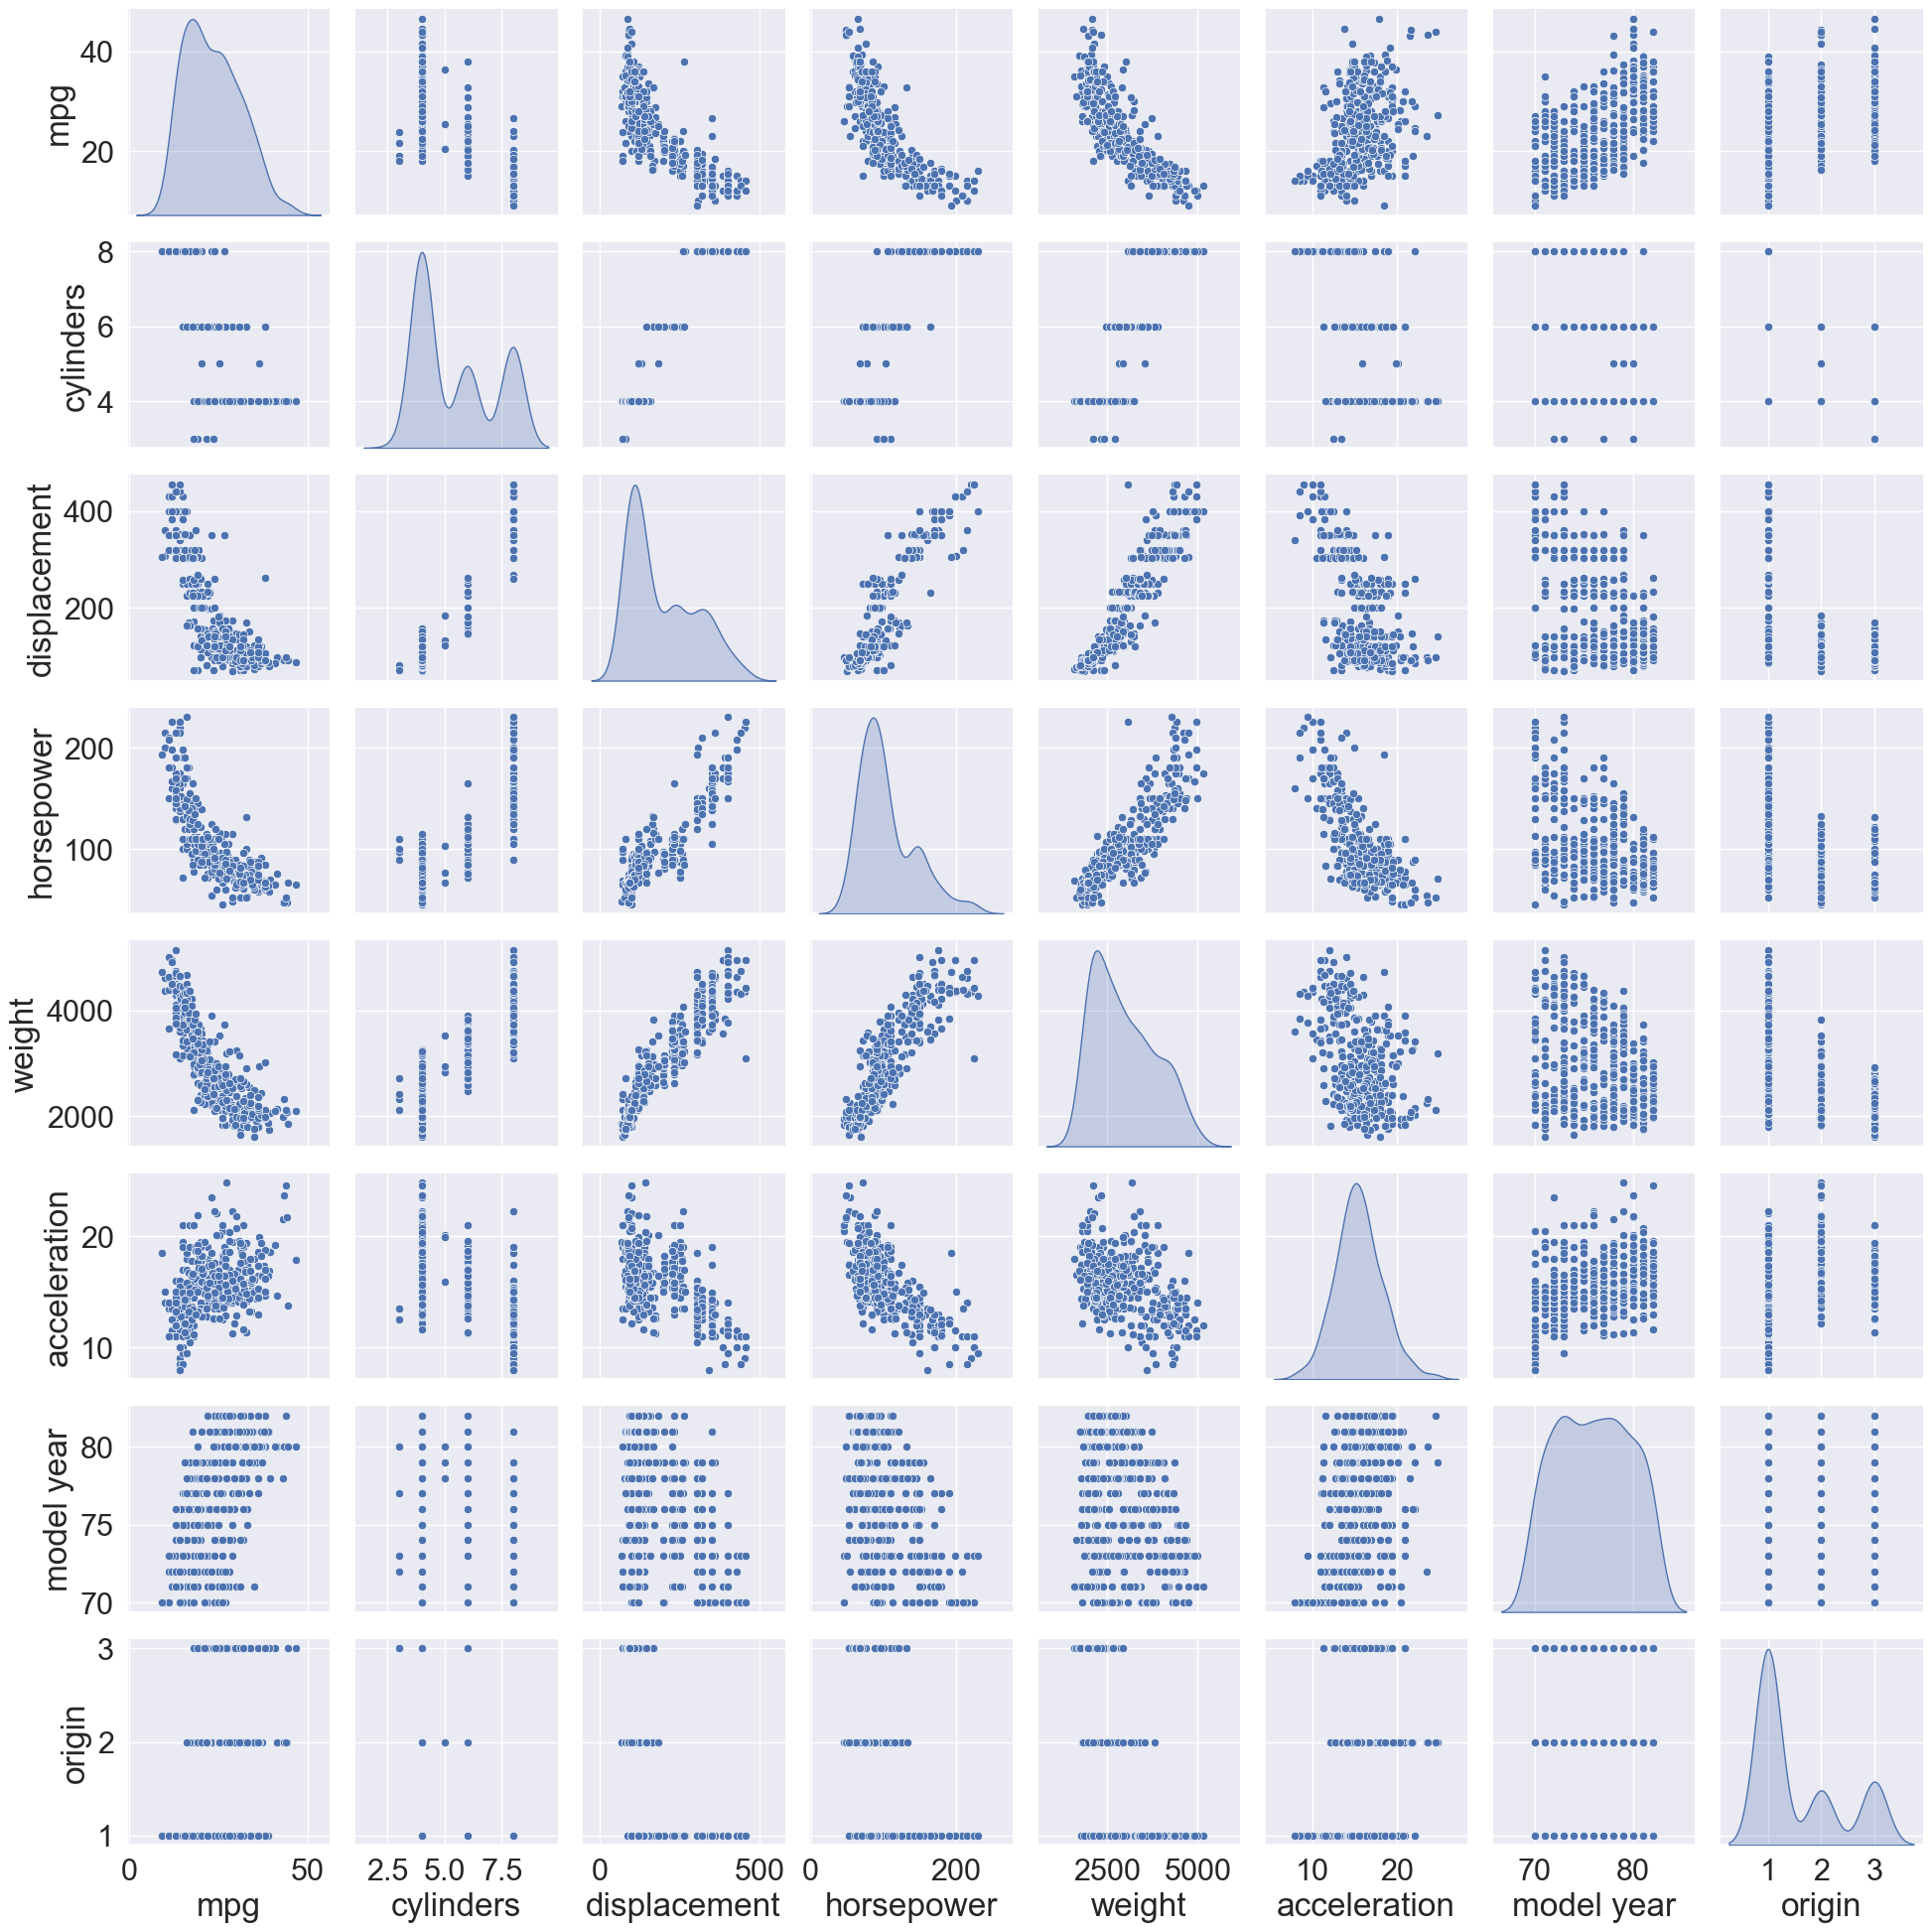

In [118]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.pairplot(df, diag_kind='kde');

## Dummy variables

In [121]:
Y=df['mpg']
X=df.drop(['mpg','car name'],axis=1)
X=pd.get_dummies(X, columns=["origin"])
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_1,origin_2,origin_3
0,8.0,307.0,130.0,3504,12.0,70,True,False,False
1,8.0,350.0,165.0,3693,11.5,70,True,False,False
2,8.0,318.0,150.0,3436,11.0,70,True,False,False
3,8.0,304.0,150.0,3433,12.0,70,True,False,False
4,8.0,302.0,140.0,3449,10.5,70,True,False,False


### Correlation between our features and targets

##### To check the correlation we will use pearson correlation coefficient. the code below will show the correlation coefficient between the target and variables. This will only check correlation between integer and float values not categorical!

In [125]:
df["car name"].value_counts()

car name
amc matador            5
ford pinto             5
toyota corolla         5
toyota corona          4
amc hornet             4
                      ..
buick skyhawk          1
chevrolet monza 2+2    1
ford mustang ii        1
pontiac astro          1
chevy s-10             1
Name: count, Length: 301, dtype: int64

In [127]:
model=[]
for x in df["car name"]:
    x = x.split()
    model.append(x[0])

In [129]:
df["manufacturer"] = model

In [131]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,manufacturer
0,18.0,8.0,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,chevrolet
1,15.0,8.0,350.0,165.0,3693,11.5,70,1,buick skylark 320,buick
2,18.0,8.0,318.0,150.0,3436,11.0,70,1,plymouth satellite,plymouth
3,16.0,8.0,304.0,150.0,3433,12.0,70,1,amc rebel sst,amc
4,17.0,8.0,302.0,140.0,3449,10.5,70,1,ford torino,ford


In [135]:
df["manufacturer"].value_counts()

manufacturer
ford             48
chevrolet        43
plymouth         31
dodge            28
amc              27
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
mazda            10
oldsmobile       10
fiat              8
peugeot           8
audi              7
vw                6
chrysler          6
volvo             6
opel              4
saab              4
subaru            4
chevy             3
renault           3
maxda             2
cadillac          2
bmw               2
mercedes-benz     2
triumph           1
vokswagen         1
mercedes          1
hi                1
capri             1
chevroelt         1
toyouta           1
nissan            1
Name: count, dtype: int64

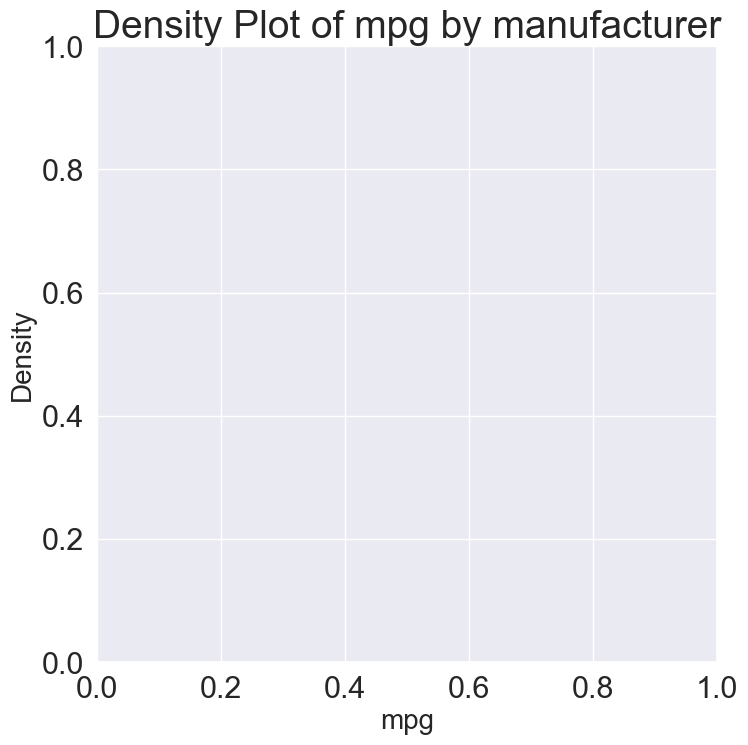

TypeError: 'NoneType' object is not subscriptable

In [142]:
brand = df.dropna(subset =["mpg"])
brand = df# Plot of distribution of mpg for manufacturer
figsize(8,8)

# Plot each manufacturer
for c_brand in brand:
    # Select the manufacturer
    subset = df[df['manufacturer'] == c_brand]
    
    # Density plot of mpg
    sns.kdeplot(subset['mpg'].dropna(),
               label = c_brand, shade = False, alpha = 0.8);
    
# label the plot
plt.xlabel('mpg', size = 20)
plt.ylabel('Density', size = 20) 
plt.title('Density Plot of mpg by manufacturer', size = 28)
plt.show()['manufacturer'].value_counts()[:4]
brand =list(brand.index)

In [146]:
# Select the numeric columns
numeric_subset = df.select_dtypes('number')

# Create columns with square root and log of numeric columns
for col in numeric_subset.columns:
    # Skip the mpg column
    if col == 'mpg':
        next
    else:
        numeric_subset['sqrt_' + col] = np.sqrt(numeric_subset[col])
        numeric_subset['log_' + col] = np.log(numeric_subset[col])

# Select the categorical columns
categorical_subset = df['manufacturer']

# One hot encode
categorical_subset = pd.get_dummies(categorical_subset)

# Join the two dataframes using concat
# Make sure to use axis = 1 to perform a column bind
features = pd.concat([numeric_subset, categorical_subset], axis = 1)

# Drop cars without an mpg
features = features.dropna(subset = ['mpg'])

# Find correlations with the building 
correlations = features.corr()['mpg'].dropna().sort_values()

In [148]:
correlations.head(10)

log_weight          -0.844194
sqrt_weight         -0.840095
weight              -0.832244
log_displacement    -0.828453
sqrt_displacement   -0.821331
log_horsepower      -0.817517
displacement        -0.805127
sqrt_horsepower     -0.802311
horsepower          -0.778427
sqrt_cylinders      -0.778352
Name: mpg, dtype: float64

In [150]:
correlations.tail(10)

acceleration         0.423329
sqrt_acceleration    0.430677
log_acceleration     0.435901
origin               0.565209
sqrt_origin          0.570802
log_origin           0.574276
log_model year       0.576519
sqrt_model year      0.578568
model year           0.580541
mpg                  1.000000
Name: mpg, dtype: float64

## Feature Engineering and Selection

#### In this project we have decided to take the following steps:

#### Select only the numerical variables and two categorical variables (borough and property use type) Add in the log transformation of the numerical variables One-hot encode the categorical variables

In [174]:
# Copy the original data
features = df.copy()

# Select the numeric columns
numeric_subset = df.select_dtypes('number')

# Create columns with log of numeric columns
for col in numeric_subset.columns:
    # Skip the mpg column
    if col == 'mpg':
        next
    else:
        numeric_subset['sqrt_' + col] = np.sqrt(numeric_subset[col])
        numeric_subset['log_' + col] = np.log(numeric_subset[col])

# Select the categorical columns
categorical_subset = df["manufacturer"]

# One hot encode
categorical_subset = pd.get_dummies(categorical_subset)

# Join the two dataframes using concat
# Make sure to use axis = 1 to perform a column bind
features = pd.concat([numeric_subset, categorical_subset], axis = 1)

features.shape

(392, 59)

## Remove colinear features

#### Highly colinear features describe the same thing so we only need one of them in our data set.

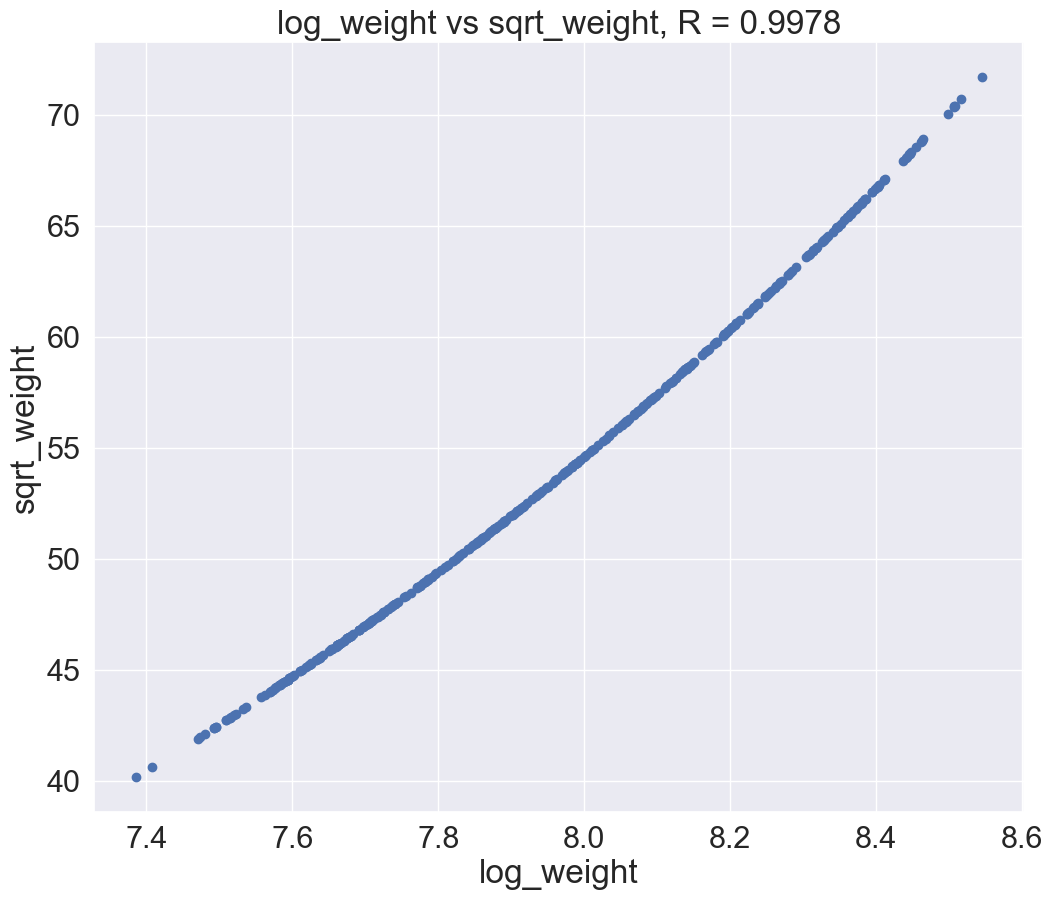

In [182]:
plot_data = features[['log_weight', 'sqrt_weight']].dropna()

plt.plot(plot_data['log_weight'], plot_data['sqrt_weight'], 'bo')
plt.xlabel('log_weight'); plt.ylabel('sqrt_weight')
plt.title('log_weight vs sqrt_weight, R = %0.4f' % np.corrcoef(features[['log_weight', 'sqrt_weight']].dropna(), rowvar=False)[0][1]);


## Split Into Training and Testing Sets

#### We are going to split our data set into training and testing sets

In [186]:
#Extract the buildings with no score and the buildings with a score
no_mpg = features[features['mpg'].isna()]
mpg = features[features['mpg'].notnull()]

print(no_mpg.shape)
print(mpg.shape)

(0, 59)
(392, 59)


In [188]:
# Separate out the features and targets
features = mpg.drop(columns='mpg')
targets = pd.DataFrame(mpg['mpg'])

# Replace the inf and -inf with nan (required for later imputation)
features = features.replace({np.inf: np.nan, -np.inf: np.nan})

# Split into 70% training and 30% testing set
X, X_test, y, y_test = train_test_split(features, targets, test_size = 0.3, random_state = 42)

print(X.shape)
print(X_test.shape)
print(y.shape)
print(y_test.shape)

(274, 58)
(118, 58)
(274, 1)
(118, 1)


## Establish a Baseline¶
#### Since it is import to establish a baseline(which is a naive guess). If our model cannot outperform a naive guess it is probably not good. our metric will be the mean absoliute error.

## Mean absolute error

In [192]:
# Function to calculate mean absolute error
def mae(y_true, y_pred):
    return np.mean(abs(y_true - y_pred))

In [194]:
baseline_guess = np.median(y)

print('The baseline guess is a score of %0.2f' % baseline_guess)
print("Baseline Performance on the test set: MAE = %0.4f" % mae(y_test, baseline_guess))

The baseline guess is a score of 23.00
Baseline Performance on the test set: MAE = 6.0585


In [196]:
# Save the no scores, training, and testing data
# import os
# os.getcwd()
no_mpg.to_csv('\\Documents\\data science\\no_mpg.csv', index = False)
X.to_csv('\\Documents\\data science\\mpg_training_features.csv', index = False)
X_test.to_csv('\\Documents\\data science\\mpg_testing_features.csv', index = False)
y.to_csv('\\Documents\\data science\\mpg_training_labels.csv', index = False)
y_test.to_csv('\\Documents\\data science\\mpg_testing_labels.csv', index = False)

In [198]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")
imputer.fit(X,y)
X= imputer.transform(X)
X_test= imputer.transform(X_test)

In [200]:
print(np.isnan(X).sum())

0


In [202]:
print(np.isnan(X_test).sum())

0


In [204]:
np.where(~np.isfinite(X))

(array([], dtype=int64), array([], dtype=int64))

In [206]:
np.where(~np.isfinite(X_test))

(array([], dtype=int64), array([], dtype=int64))

In [208]:
scaler = MinMaxScaler (feature_range=(0,1))
scaler.fit(X,y)
scaler.transform(X)
scaler.transform(X_test)

array([[0.2       , 0.06753247, 0.11538462, ..., 0.        , 0.        ,
        0.        ],
       [0.2       , 0.13246753, 0.36813187, ..., 0.        , 0.        ,
        0.        ],
       [0.2       , 0.05454545, 0.06593407, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.2       , 0.12727273, 0.28571429, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.64415584, 0.50549451, ..., 0.        , 0.        ,
        0.        ],
       [0.6       , 0.46753247, 0.13186813, ..., 0.        , 0.        ,
        0.        ]])

In [210]:
y = np.array(y).reshape((-1,))
y_test = np.array(y_test).reshape((-1,))

In [212]:
def rmse (y_true,y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

In [214]:
def model_test(model):
    model.fit(X,y)
    predictions = model.predict(X_test)
    model_rsme = rmse(y_test,predictions)
    return model_rsme

In [216]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [218]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

In [220]:
lr = LinearRegression()
lr_rsme = model_test(lr)
print(" the root mean squared error for linear regression is:", lr_rsme)

 the root mean squared error for linear regression is: 2.8625006253099823


In [222]:
knn = KNeighborsRegressor(n_neighbors=5)
knn_rsme = model_test(knn)
print(" the root mean squared error for K nearest neighbors is:", knn_rsme)

 the root mean squared error for K nearest neighbors is: 4.3192356511505015


In [224]:
svm = SVR()
svm_rsme = model_test(svm)
print(" the root mean squared error for Support vector machine is:", svm_rsme)

 the root mean squared error for Support vector machine is: 3.9446062808320677


In [226]:
tree = DecisionTreeRegressor()
tree_rsme = model_test(tree)
print(" the root mean squared error for decision tree is:", tree_rsme)

 the root mean squared error for decision tree is: 3.482060562757613


In [228]:
xgb = XGBRegressor(objective='reg:squarederror')
xgb_rsme = model_test(xgb)
print(" the root mean squared error for XGB Regressor is:", xgb_rsme)

 the root mean squared error for XGB Regressor is: 2.736867543530519


In [230]:
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
rf_rsme = model_test(rf)
gb_rsme = model_test(gb)

In [232]:
print(" the root mean squared error for randoom forest is:", rf_rsme)

 the root mean squared error for randoom forest is: 2.6189345550032015


In [234]:
print(" the root mean squared error for gradient boosting is:", gb_rsme)

 the root mean squared error for gradient boosting is: 2.74705035512234


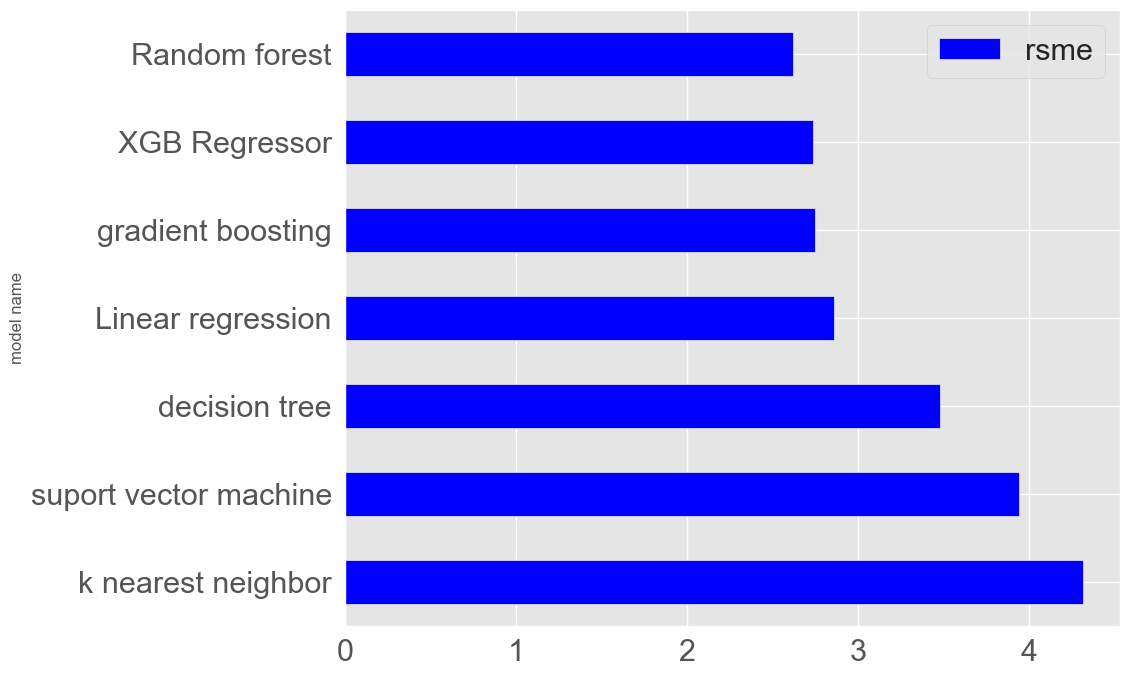

In [236]:
figsize(10,8)

plt.style.use("ggplot")
model_comparison = pd.DataFrame({"model name":["Linear regression", "k nearest neighbor", "suport vector machine",
                                              "decision tree","XGB Regressor", "Random forest", "gradient boosting"],
                                "rsme": [lr_rsme,knn_rsme,svm_rsme,tree_rsme,xgb_rsme,rf_rsme,gb_rsme]})
model_comparison = model_comparison.sort_values("rsme", ascending=False).plot(x="model name", y="rsme", color="blue", kind="barh")

In [238]:
booster=['gbtree','gblinear']
base_score=[0.25,0.5,0.75,1]

In [242]:
## Hyper Parameter Optimization

n_estimators = [100, 500, 900, 1100, 1500]
max_depth = [2, 3, 5, 10, 15]
booster=['gbtree','gblinear']
learning_rate=[0.05,0.1,0.15,0.20]
min_child_weight=[1,2,3,4]

# Define the grid of hyperparameters to search
hyperparameter_grid = {
    'n_estimators': n_estimators,
    'max_depth':max_depth,
    'learning_rate':learning_rate,
    'min_child_weight':min_child_weight,
    'booster':booster,
    'base_score':base_score
    }

In [244]:
from sklearn.model_selection import RandomizedSearchCV

# Set up the random search with 4-fold cross validation
random_cv = RandomizedSearchCV(estimator=xgb,
            param_distributions=hyperparameter_grid,
            cv=5, n_iter=50,
            scoring = 'neg_mean_absolute_error',n_jobs = 4,
            verbose = 5, 
            return_train_score = True,
            random_state=42)

In [246]:
random_cv.fit(X,y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" }

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=4,
                   param_distributions={'base_score': [0.25, 0.5, 0.75, 1],
                                        'booster': ['gbtree', 'gblinear'],
                                        'learning_rate': [0.05, 0.1, 0.15, 0.2],
                                        'max_depth': [2, 3, 5, 10, 15],
                                        'min_child_weight': [1, 2, 3, 4],
                                        'n_estimators': [100, 500, 900, 1100,
                                                         1500]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=5)

In [248]:
random_cv.best_estimator_

XGBRegressor(base_score=0.75, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None, ...)

In [250]:
from sklearn.model_selection import GridSearchCV


trees_grid = {"n_estimators":[100,150,200,250,300,350,400,450],
             }

grid_search = GridSearchCV(estimator=xgb,n_jobs=1,param_grid=trees_grid,
                           scoring="neg_mean_absolute_error",cv=10,verbose=1,return_train_score=True)

In [252]:
grid_search.fit(X,y)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'n_estimators': [100, 150, 200, 250, 300, 350, 400,
                                          450]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

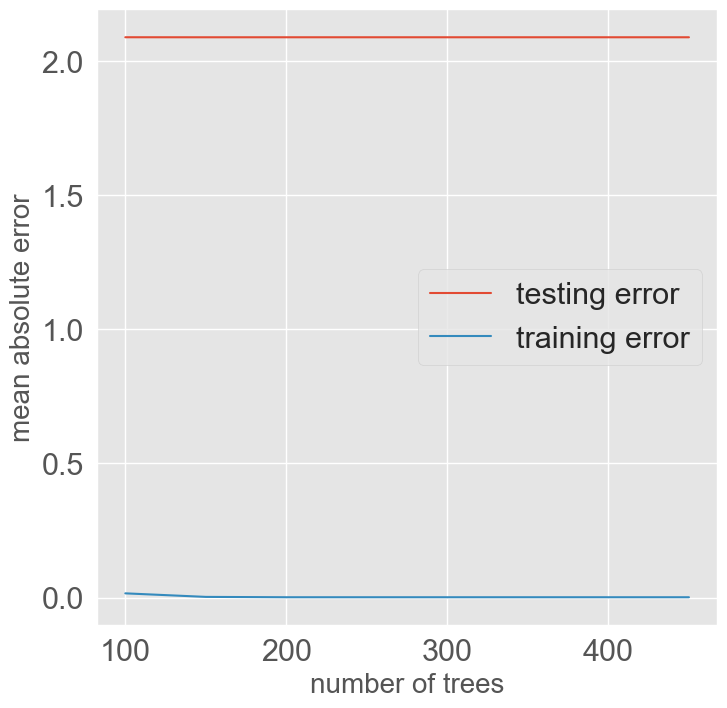

In [254]:
results = pd.DataFrame(grid_search.cv_results_)
figsize(8,8)
plt.style.use("ggplot")
plt.plot(results["param_n_estimators"], -1*results["mean_test_score"], label="testing error")
plt.plot(results["param_n_estimators"], -1*results["mean_train_score"], label="training error")
plt.legend()
plt.ylabel("mean absolute error", size=20)
plt.xlabel("number of trees", size= 20)
plt.show()

In [256]:
default_model = XGBRegressor(objective='reg:squarederror')
final_model = grid_search.best_estimator_
final_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [258]:
%%timeit -n 1 -r 5
default_model.fit(X,y)

53.2 ms ± 16.9 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [260]:
%%timeit -n 1 -r 5
final_model.fit(X,y)

65.1 ms ± 21.3 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [262]:
default_pred = default_model.predict(X_test)
final_pred = final_model.predict(X_test)

In [264]:
print("the default model performance on the test set: rsme = %0.4f"  %rmse(y_test,default_pred))
print("the final model performance on the test set: rsme = %0.4f" %rmse(y_test,final_pred))

the default model performance on the test set: rsme = 2.7369
the final model performance on the test set: rsme = 2.7394


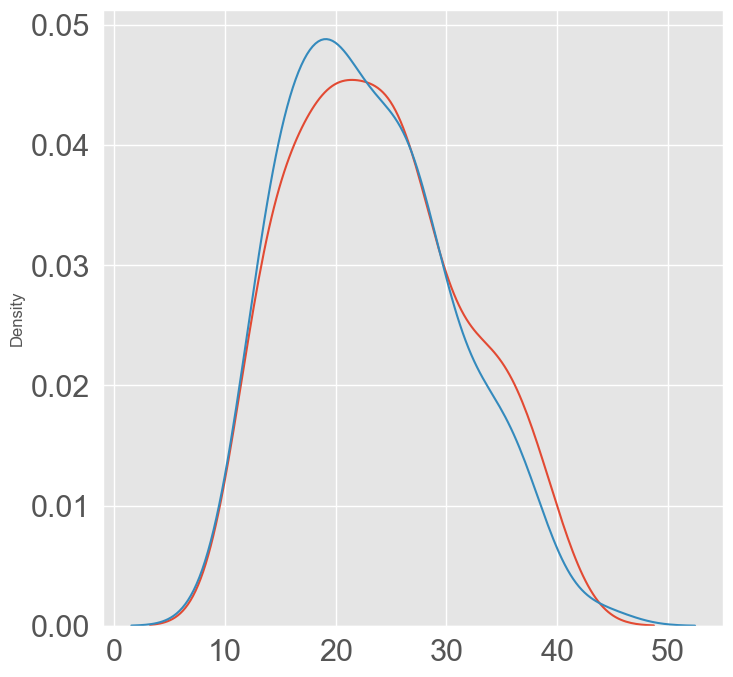

In [266]:
figsize(8,8)
sns.kdeplot(final_pred, label="predictions")
sns.kdeplot(y_test, label="test values")
plt.show()

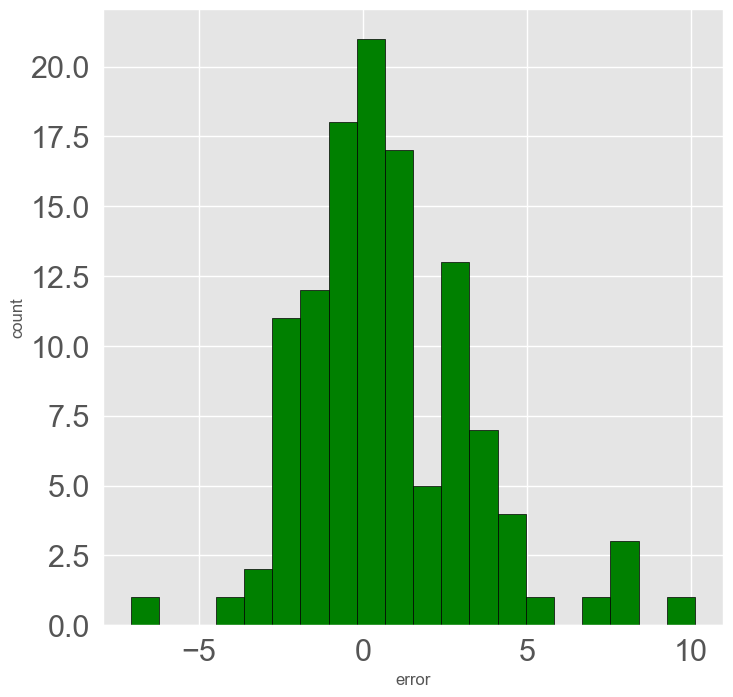

In [268]:
figsize =(6,6)
residuals = final_pred - y_test

plt.hist(residuals, color = "green", bins=20, edgecolor="black")
plt.ylabel("count")
plt.xlabel("error")
plt.show()

In [275]:
ann_pred = model.predict(X_test)
score = rmse(y_test,ann_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [277]:
score

193.37023972635046